# Creating a LSTM Forecast model
[📥 Download Notebook](https://github.com/Mosqlimate-project/mosqlimate-client/blob/main/docs/tutorials/lstm_model.ipynb)
 
In this notebook we will show how to create a LSTM forecast model using the `mosqlient` package.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

To download epidemiological data, provide your Mosqlimate API key:

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("MOSQLIMATE_API_KEY")

Import the required packages

In [8]:
import torch
import pandas as pd
from datetime import date
import mosqlient as mosq 
import matplotlib.pyplot as plt 
from mosqlient.forecast import ForecastLSTM
from mosqlient.forecast.viz import plot_training_model_loss, plot_model_comparison, plot_single_forecast

### Load the dataset

Retrieve historical dengue data from Infodengue.

In [9]:
df = mosq.get_infodengue(
    api_key=api_key,
    disease="dengue",
    uf="SC",
    geocode=4209102, 
    start_date= '2020-01-01', 
    end_date = '2026-07-09'
)

df.head()

100%|██████████| 1/1 [00:00<00:00,  1.42requests/s]


,data_iniSE,SE,casos_est,casos_est_min,casos_est_max,casos,municipio_geocodigo,p_rt1,p_inc100k,Localidade_id,...,nivel_inc,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf
0,2020-01-05,202002,4.0,4,4,4,4209102,0.936549,0.669279,0,...,0,83.459870,67.167763,26.904763,31.142857,2,None,None,None,None
1,2020-01-12,202003,4.0,4,4,4,4209102,0.806532,0.669279,0,...,0,76.313103,57.508696,25.229741,28.714286,0,None,None,None,None
2,2020-01-19,202004,5.0,5,5,5,4209102,0.730510,0.836599,0,...,0,80.768472,66.393386,23.968254,27.142857,3,None,None,None,None
3,2020-01-26,202005,5.0,5,5,5,4209102,0.615577,0.836599,0,...,0,82.987376,66.186968,26.634503,30.571429,4,None,None,None,None
4,2020-02-02,202006,17.0,17,17,17,4209102,0.995212,2.844436,0,...,0,91.164054,86.112502,24.359410,25.571429,12,None,None,None,None


The model expects a target variable together with any predictor variables.

In this example:

* `casos` is the target variable.
* `tempmin`, `umidmin`, and `Rt` are explanatory variables.

In [10]:
columns = [
    "data_iniSE",
    "casos",
    "tempmin",
    "umidmin",
    "Rt",
]

### Define the model hyperparameters

These parameters control the neural network architecture and forecasting horizon.


| Parameter    | Description                                              |
| ------------ | -------------------------------------------------------- |
| `look_back`  | Number of previous time steps used as input.             |
| `predict_n`  | Number of future time steps predicted at each iteration. |
| `hidden`     | Number of hidden units in each LSTM layer.               |
| `features`   | Number of input features (excluding the date column).    |
| `dropout`    | Dropout probability used for regularization.             |
| `num_layers` | Number of stacked LSTM layers.                           |



In [11]:
look_back = 4
predict_n = 4

hidden = 16
features = 4
dropout = 0.2
num_layers = 3

criterion = torch.nn.MSELoss()

### Create the forecasting model

Instantiate the ForecastLSTM class.

In [12]:
target_col = 'casos'
FOR_Model = ForecastLSTM(
    df_data=df,
    columns=columns,
    date_col="data_iniSE",
    target_col=target_col,
    hidden=hidden,
    features=features,
    predict_n=predict_n,
    look_back=look_back,
    dropout=dropout,
    num_layers=num_layers,
)

### Train the model

Define the preprocessing options and training period.

The training method automatically performs:

data preprocessing;
optional log transformation (use_log = True);
feature normalization: 
- "max": Divides data by the column-wise maximum (x / max).
- "robust": Subtracts the median and divides by the IQR ((x - median) / IQR).

creation of training and validation datasets;
neural network training with early stopping.

In [13]:
use_log = True
method = "robust"

ini_train_date = "2020-01-01"
end_train_date = "2024-12-31"
end_date = "2025-12-31"

model, hist = FOR_Model.train(
    ini_train_date=ini_train_date,
    end_train_date=end_train_date,
    end_date=end_date,
    use_log=use_log,
    method=method,
    batch_size=2,
    epochs=100,
    patience=30,
    criterion=criterion,
    lr=0.001,
    device="cuda",
)

Epoch 1/100 | Train: 0.4595 | Val: 0.3968
Epoch 2/100 | Train: 0.2797 | Val: 0.0782
Epoch 3/100 | Train: 0.1323 | Val: 0.0513
Epoch 4/100 | Train: 0.1020 | Val: 0.0433
Epoch 5/100 | Train: 0.0764 | Val: 0.0403
Epoch 6/100 | Train: 0.0658 | Val: 0.0406
Epoch 7/100 | Train: 0.0736 | Val: 0.0414
Epoch 8/100 | Train: 0.0627 | Val: 0.0356
Epoch 9/100 | Train: 0.0749 | Val: 0.0372
Epoch 10/100 | Train: 0.0606 | Val: 0.0365
Epoch 11/100 | Train: 0.0592 | Val: 0.0356
Epoch 12/100 | Train: 0.0632 | Val: 0.0330
Epoch 13/100 | Train: 0.0546 | Val: 0.0333
Epoch 14/100 | Train: 0.0626 | Val: 0.0307
Epoch 15/100 | Train: 0.0549 | Val: 0.0321
Epoch 16/100 | Train: 0.0581 | Val: 0.0305
Epoch 17/100 | Train: 0.0565 | Val: 0.0315
Epoch 18/100 | Train: 0.0505 | Val: 0.0327
Epoch 19/100 | Train: 0.0528 | Val: 0.0300
Epoch 20/100 | Train: 0.0419 | Val: 0.0303
Epoch 21/100 | Train: 0.0543 | Val: 0.0278
Epoch 22/100 | Train: 0.0514 | Val: 0.0280
Epoch 23/100 | Train: 0.0476 | Val: 0.0262
Epoch 24/100 | Train

Plot the training and validation losses.

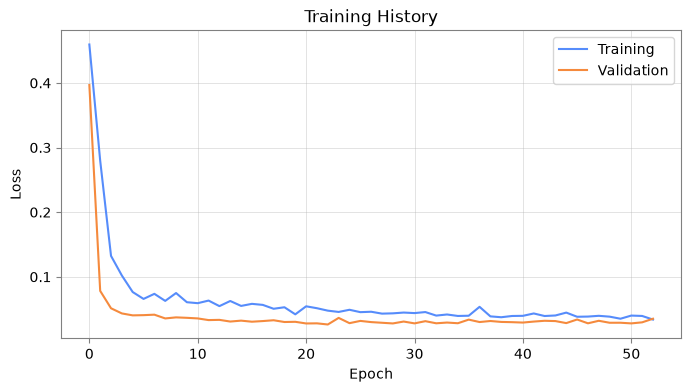

In [14]:
_, ax = plot_training_model_loss(hist)

### In sample performance: 

Generate predictions for the training period.

The returned dataframe contains:

- last observed date used to make the forecast; 
- forecast date;
- prediction horizon;
- observed values;
- predictive distribution statistics.


In [15]:
df_preds_train = FOR_Model.predict_in_sample()

df_preds_train.head()

,last_date,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,horizon,casos
0,2020-01-26,2020-02-02,16.071518,17.909849,19.492638,23.420679,32.862808,41.916836,54.557522,58.633087,66.745392,1,17
1,2020-01-26,2020-02-09,19.388607,21.284197,23.856852,28.514011,39.081173,50.478935,61.563374,67.285072,69.198914,2,56
2,2020-01-26,2020-02-16,24.691383,25.877281,27.690243,34.557602,45.016335,58.922916,70.771217,78.189377,85.183670,3,80
3,2020-01-26,2020-02-23,28.664660,29.736393,31.451944,39.383526,53.721680,71.151947,90.239204,98.633636,101.928802,4,81
4,2020-02-02,2020-02-09,22.689873,24.841272,26.774704,34.560966,43.702728,58.098122,70.099556,82.360435,106.639862,1,56


Visualize the one-step-ahead forecasts.

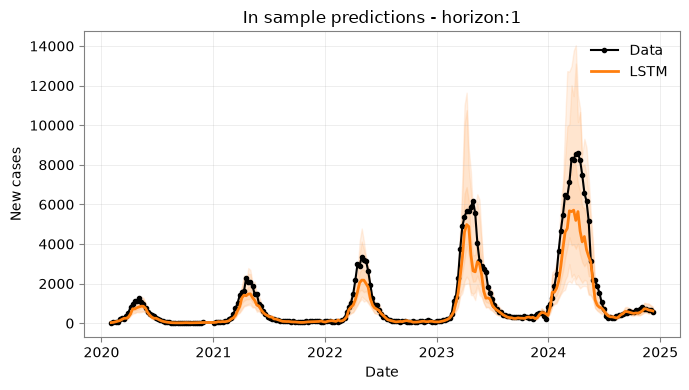

In [16]:
horizon =1 

_,ax = plot_model_comparison(
    df_preds = df_preds_train.loc[df_preds_train.horizon == horizon],
    date_col = "date",
    target_col = "casos",
    label = "LSTM",
    conf_levels=[0.5, 0.90, 0.95],
    title = f"In sample predictions - horizon:{horizon}",
    xlabel= "Date",
    ylabel = "New cases")

### Evaluate out-of-sample performance

Generate predictions for the test period.

In [17]:
df_preds_test = FOR_Model.predict_out_of_sample()

df_preds_test.head()

,last_date,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,horizon,casos
0,2024-12-29,2025-01-05,379.642700,398.486420,409.144135,443.183319,490.587585,546.814026,586.637146,601.005249,634.129272,1,589
1,2024-12-29,2025-01-12,380.577118,397.540863,414.405304,437.263916,483.072174,534.172546,561.238953,576.287781,600.385986,2,548
2,2024-12-29,2025-01-19,373.967255,381.573792,394.024109,421.372314,464.358521,512.796509,529.372742,542.393494,563.619080,3,552
3,2024-12-29,2025-01-26,358.154480,377.103485,382.654694,405.797791,446.725830,489.776306,515.844849,526.441162,533.049072,4,536
4,2025-01-05,2025-01-12,433.283813,444.095093,487.619507,513.640808,563.737915,649.987671,713.834717,757.432617,831.090332,1,548


Visualize the one-step-ahead forecasts.

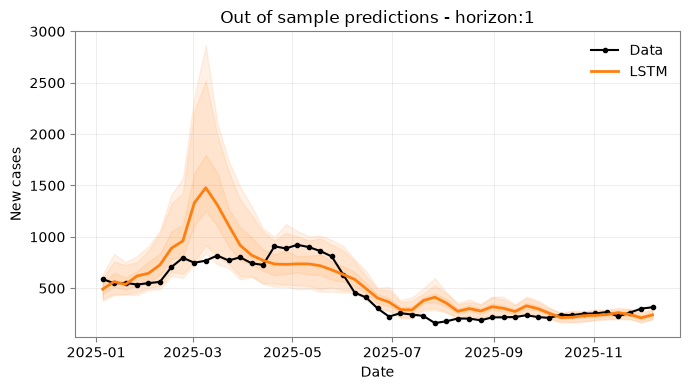

In [18]:
horizon =1 

_,ax = plot_model_comparison(
    df_preds = df_preds_test.loc[df_preds_test.horizon == horizon],
    date_col = "date",
    target_col = "casos",
    label = "LSTM",
    conf_levels=[0.5, 0.90, 0.95],
    title = f"Out of sample predictions - horizon:{horizon}",
    xlabel= "Date",
    ylabel = "New cases")

### Generate future forecasts

After training, the model can generate forecasts beyond the available observations. The forecasting process starts from the last date specified in the `end_date` parameter used during training. This date must fall within the time range of the `df_data` provided when initializing the `ForecastLSTM` class. The method automatically reuses the preprocessing parameters (such as normalization and optional log transformation) learned during training, ensuring that new input data are scaled consistently before generating forecasts.

In [19]:
df_forecast = FOR_Model.forecast(
    end_date="2025-01-05",
    n_samples=100,
)

df_forecast.head()

,last_date,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,horizon
0,2025-01-05,2025-01-12,446.530914,457.024902,477.286835,516.826172,585.965454,675.478516,740.154175,767.682434,792.468323,1
1,2025-01-05,2025-01-19,460.379822,468.673340,491.066711,528.462769,588.421082,671.502930,734.155884,749.113708,766.193054,2
2,2025-01-05,2025-01-26,445.106079,461.029785,478.417053,522.125549,574.892944,660.185913,713.310486,736.053589,747.081726,3
3,2025-01-05,2025-02-02,443.954956,462.413696,481.167938,519.337036,573.579041,640.198425,677.997437,716.127869,720.307861,4


Plot the forecasts: 

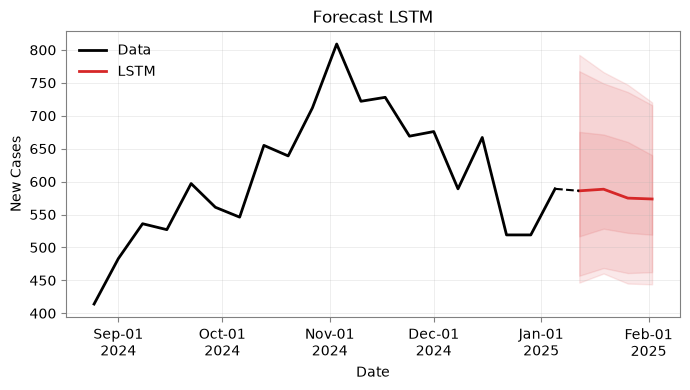

In [20]:
_,ax = plot_single_forecast(
    df_for = df_forecast,
    df_train=FOR_Model.df_model.reset_index().rename(columns = {'data_iniSE': 'date'}),
    last_obs = 20,
    target_col=target_col,
    date_col="date",
    conf_levels=[0.5, 0.90, 0.95],
    title="Forecast LSTM",
    label="LSTM",
    xlabel="Date",
    ylabel="New Cases",
    figsize=(7, 4))